<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Linear Regression Example <span style="font-size: small">(a very special case of a neural network)</span>

## Bike Sharing Demand
 - data set of *bike rental counts* in a Washington, D.C., bikeshare program 
 - much simplified data table with only
    - ```temp``` - temperature in Celsius
    - ```count``` - number of total rentals
    for individual hours during daytime and summer
    - other features like humidity, weekday, holiday and time of day ignored
 - **task**: predict bike rental demand (count of bikes) based on temperature
 - data source: [kaggle](https://www.kaggle.com/c/bike-sharing-demand)

Import libraries
 - [Pandas](https://pandas.pydata.org) for reading input tables from a file to a *data frame*.
 - [Matplotlib](https://matplotlib.org) for making plots.
 - [TensorFlow](https://www.tensorflow.org) to compute gradients and general machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf # at least version 2 
import math

2025-03-06 10:58:50.877376: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-06 10:58:50.877571: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-06 10:58:50.880091: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-06 10:58:50.910802: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-06 10:58:51.508669: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

In [2]:
# load the training data from the table file to a pandas data frame
df = pd.read_csv("bikes-summerdays.tbl", sep = '\s+') # cols are split by at least one white space
df.head()

,temp,count
0,13.12,173
1,13.12,75
2,13.12,89
3,13.94,95
4,14.76,110


In [3]:
# convert count data from integer to float as regression target
df['count'] = df['count'].astype(float) 
df.dtypes

temp     float64
count    float64
dtype: object

The basic data structure of ML frameworks is the **Tensor** (or ndarray in numpy).
A tensor is a collection of numbers (in most cases with datatype float) with a specific **shape**.
The **shape** of a tensor is a tuple of numbers, where the length of the tuple is the number of **axes** or **rank** of the tensor and values are the **dimensions** or **depths** of the axes.

Our data is a 2-D (of rank 2 or with 2 axes) tensor with the following shape:

In [4]:
df.shape

(1482, 2)

(In fact, it's currently not a "tensor" per se, but a **pandas dataframe** that has not been converted to a numpy or tensorflow representation)

In [5]:
type(df)

pandas.core.frame.DataFrame

In [6]:
# assign training set size and number of columns to variable for later
m, n_cols = df.shape 

# compute average of hourly bike rental counts
meancount = np.mean(df['count'])
print ("mean bike count = ", meancount)

mean bike count =  311.0


### Make a first explorative plot

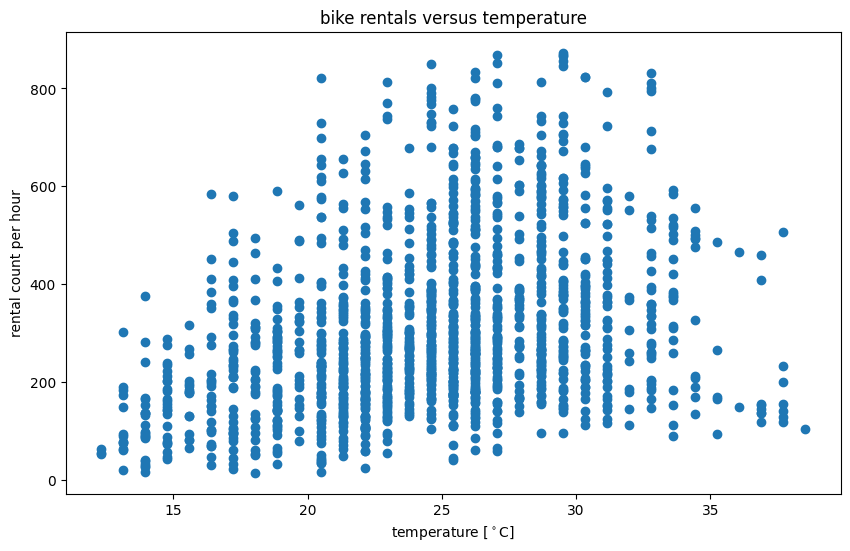

In [7]:
def scatterplot_rentals():
    ''' Plot the bike rental counts versus the temperature.'''
    _, ax = plt.subplots(figsize = (10, 6)) # width x height
    ax.scatter(df["temp"], df["count"])
    plt.title("bike rentals versus temperature")
    plt.xlabel('temperature [' + r'$^\circ$' + 'C]')
    plt.ylabel('rental count per hour');
    return ax

ax = scatterplot_rentals();

In [8]:
# print summary statistics 
df.describe()

,temp,count
count,1482.000000,1482.000000
mean,24.612173,311.000000
std,4.979788,174.792339
min,12.300000,14.000000
25%,21.320000,184.000000
50%,24.600000,272.000000
75%,27.880000,398.750000
max,38.540000,873.000000


## Define the loss function

In [9]:
# Mean squared error loss function that depends on the predictions.
def MSE(yhat):
    """
        Mean squared error function for linear regression
        yhat: The predictions of shape (m,1). 
    """
    # now theta is a matrix in any case
    d = (yhat - y_train.reshape((-1, 1)))**2 # square the residuals ('errors')
    E = tf.reduce_sum(d, axis = 0) / m
    return E

## Baseline performance

Let's say we would have trained a model. How do we know we actually achieved something? We could look at the loss or some metric and see if it has decreased, but is that enough? 

Let's say you are given a trained model on a classification task that achieves $95\%$ accuracy (i.e. it is correct in $95\%$ of all cases). Can you say right away this is a good model?

No you can't (why?). 

We need a naive baseline to compare against. For a regression task, we can compute the error of a model, that always predicts the mean of the regression targets.

In [10]:
# stack the mean value in a (m,1) tensor
naive_yhat = np.repeat(meancount, m)
naive_yhat = np.expand_dims(naive_yhat, -1)
naive_yhat

array([[311.],
       [311.],
       [311.],
       ...,
       [311.],
       [311.],
       [311.]])

In [11]:
# extract response vector
y_train = np.array(df['count']) 

# check the loss of the baseline model
# also observe that the output is a tf.Tensor (because we used tf functions in MSE)
# This will be important later.
MSE(naive_yhat)

2025-03-06 10:58:52.572281: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-06 10:58:52.572636: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


<tf.Tensor: shape=(1,), dtype=float64, numpy=array([30531.7462888])>

## Linear Regression

Input variables $x_1,\ldots, x_n$ (<span style="color:red">features</span>). Here: $n=1$ and $x_1=$ temperature.

Real valued output variable $y$ (aka <span style="color:red">response</span> variable). Here, $y=$ bike count.

### Hypothesis function
Let ${\bf x}=(x_1,\ldots, x_n)$ be an input vector and 
$$\pmb{\theta} = \begin{pmatrix}\theta_0\\\vdots\\ \theta_n\end{pmatrix}$$

be a vector of unknown coefficients (<span style="color:red">parameters</span>). The function

$$h_{\pmb{\theta}}({\bf x}) := \theta_0 + \theta_1 x_1 + \cdots \theta_n x_n = (1, x_1, \cdots, x_n) \cdot \pmb{\theta}$$

is called the <span style="color:red">hypothesis</span>.

**Aim**: Find parameters $\pmb{\theta}$ such that, roughly speaking,
$h_{\pmb{\theta}}({\bf x}) \approx y$
for most *examples* $({\bf x}, y)$ from a data set or data distribution.

### Data set
Let $m$ be the number of training examples (pairs of input/output), 

$${\bf X} := \begin{pmatrix}
1 & x^{(1)}_1 & x^{(1)}_2 & \cdots & x^{(1)}_n\\
\vdots & \vdots & \vdots & &\vdots\\ 
1 & x^{(m)}_1 & x^{(m)}_2 & \cdots & x^{(m)}_n\\
\end{pmatrix} = \left(x^{(i)}_j\right)_{\tiny\begin{array}{l}1\le i\le m\\ 0\le j \le n\end{array}
},$$

be the *data matrix*, where $x^{(i)}_j$ is the value of the $j$-th feature of the $i$-th example, $x_0^{(j)}:=1$, and 

$${\bf y} = \begin{pmatrix}y_1\\\vdots\\y_m\end{pmatrix}$$

be the vector of responses.


### Mean squared error function
Define the *mean squared error* function

$$\text{MSE}(\pmb{\theta}) = \frac{1}{m} ({\bf X} \pmb{\theta} - {\bf y})^2  
= \frac{1}{m} \sum_{i=1}^m \left(h_{\pmb{\theta}}({\bf x}^{(i)}) - y_i\right)^2, \qquad \qquad (1)$$

where the square is meant to be applied componentwise to a vector. In machine learning (ML), $\text{MSE}$ is called a
<span style="color:red">loss function</span>. It is our target to be minimized:

$$ \text{MSE}(\pmb{\theta}) \to \min$$

## Create Data Matrix $X$ and response vector $y$

In [12]:
# extract feature columns
n = n_cols - 1 # number of features
temps = np.array(df.loc[:, df.columns != 'count']) # matrix of all other columns (here only one col)

# make data matrix X
X_train = np.ones((m, n+1)) # initialize with all ones
# overwrite all but the zero-th column with features

# normalize temperatures so they are roughly in [-1,1] 
X_train[:, 1:n+1] = temps / 10 - 2.5

# print first 5 examples
print("X_train:\n ", X_train[0:5,], "\ny_train :" , y_train[0:5])

X_train:
  [[ 1.    -1.188]
 [ 1.    -1.188]
 [ 1.    -1.188]
 [ 1.    -1.106]
 [ 1.    -1.024]] 
y_train : [173.  75.  89.  95. 110.]


## Implement the model

In [13]:
def linear_regression(X_train, theta):
    """
        Makes predictions on input data under a linear regression model with parameters theta.
        X_train: The data matrix
        theta: array of parameters, the first dimension must match the number of cols of X
               If theta is 2-dimensional, the output is 1-dim with one entry per col of theta.
    """
    if len(theta.shape) == 1: # theta is 1-dimensional
        theta = tf.reshape(theta, (-1, 1)) # make it a matrix with one column
    yhat = tf.linalg.matmul(X_train, theta) # vector of predicted rental counts
    return yhat

In [14]:
# this is for lecture purposes only
# your are not required to read it to understand the lesson
def contourPlot():
    ''' Plot the error landscape'''
    # compute error for the grid of all combinations of theta0 and theta1 values
    theta0 = theta1 = np.arange(-3200., 3200., 100) # grid axis ranges
    xv, yv = np.meshgrid(theta0, theta1) # x and y values of all grid points
    Theta = np.array([xv, yv]).reshape(2, -1) # 2 rows, one col per grid point

    # compute error for all grid points
    z = MSE(linear_regression(X_train, Theta)).numpy()
    z = z.reshape((theta0.size, -1)) # make this a matrix again as required by contour

    ## make contour plot
    _, axC = plt.subplots(figsize = (9, 8))
    # heights to draw contour lines for
    h = [50000, 200000] + list(range(500000, 6000001, 500000))
    contours = axC.contour(theta0, theta1, z, levels=h, colors='black')
    axC.clabel(contours, inline=True, fontsize=8, fmt='%i') # labels on lines
    plt.title("mean squared error " + r'$E(\theta)$');
    plt.xlabel(r'$\theta_0$')
    plt.ylabel(r'$\theta_1$');
    return axC

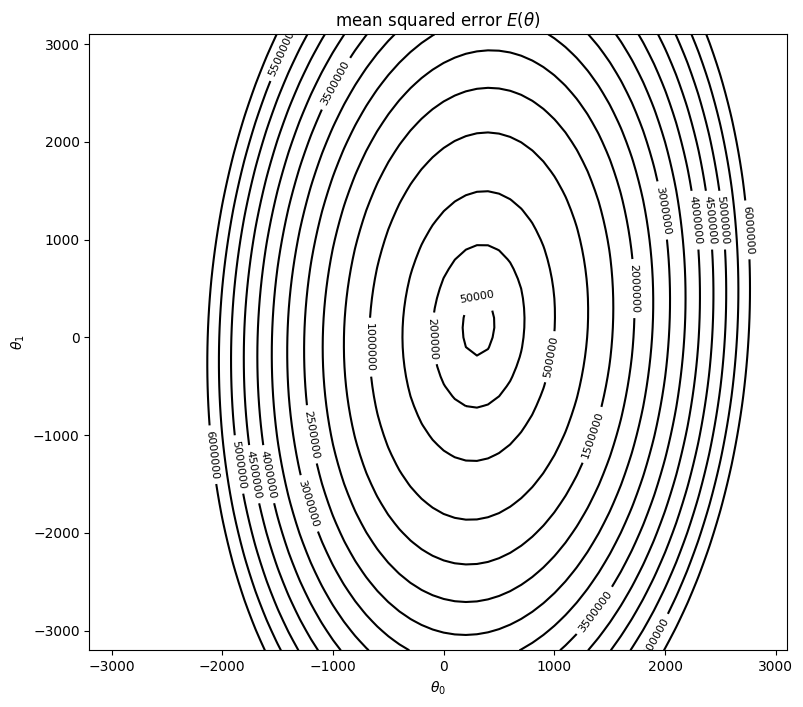

In [15]:
axC = contourPlot()

## Gradient and Gradient Descent
Gradient descent is a simple optimization algorithm, where the parameters are iteratively updated, by moving each time a (small) step into the direction of the steepest descend of the target function to be minimized:
$$ \pmb{\theta} \leftarrow \pmb{\theta} - \alpha \cdot\nabla \;\text{MSE}(\pmb{\theta})
\qquad \qquad \qquad (2)$$

Here, 
$$\nabla\; \text{MSE}(\pmb{\theta}) = \left(\frac{\partial\, \text{MSE}(\pmb{\theta})}{\partial\, \theta_0} , 
\ldots, \frac{\partial\, \text{MSE}(\pmb{\theta})}{\partial\, \theta_n}\right)^T$$ 
is the *gradient* of the mean squared error function in the point $\pmb{\theta}$ and $\alpha$ is called the *learning rate*. 

The rationale (not guaranteed) is that $\pmb{\theta}$ may converge to a *local* optimum. 
In applications other than linear regression a local optimum may not even be global.
In ML practice, usually a little more sophisticated methods are used, but they also require iterative updates based on the gradient.

*In order to compute the gradient we need a differentiable loss function. In modern Deep Learning, we **never** compute gradients by hand. We let TensorFlow automatically compute the gradients.*

*This requires that **all functions** used to compute the predictions ($\hat{y}$) and the loss are (differentiable) TensorFlow functions. Scroll up and check that this is indeed the case for our MSE and* `linear_regression` *implementations*

## Solution 1: low-level approach
Let us first (but never later) do it with a simple self-implemented gradient descent.

In [16]:
def gradient_descent(theta_init, learning_rate):
    ''' Simple gradient descent algorithm.'''
    N = 100 # number of update steps
    alpha = learning_rate
    
    # create variable for model parameters (weights) and initialize it
    theta = tf.Variable(theta_init, dtype = tf.float64, name = "weights", trainable = True)
    
    # variable to monitor progress
    err = np.zeros(N + 1) # error after each update step
    Theta = np.zeros((2, N + 1)) # sequence of parameters after each step
    
    # simple gradient descent loop
    for i in range(N + 1):        
        with tf.GradientTape() as tape: # to be explained and practiced later
            yhat = linear_regression(X_train, theta)
            E = MSE(yhat)
        
        Theta[:, i] = theta.numpy()
        err[i] = E.numpy().squeeze()
        if i < N + 1:
            grad = tape.gradient(E, theta) # let tf compute the derivate of E wrt to theta
            theta.assign(theta - alpha * grad) # core update step from formula (2)
            if (i%10 == 0): # output some algorithm progress
                print ("error after ", i, " iterations: ", err[i], " gradient= ", grad.numpy())
    return [Theta, err]

## Visualization of optimization progress

In [17]:
def plot_error(err, col):
    ''' Plot error over time'''
    plt.subplots()
    plt.plot(np.log(err), 'o-', color=col, linewidth=.2, markersize=3, mfc='none')
    plt.title("Log error by iteration of gradient descent")
    plt.xlabel('iteration '+r'$i$')
    plt.ylabel(r'$ln \;E(\theta^{(i)})$');

def plot_progress(Theta, err, col, ):
    '''Plot error and parameters over time'''
    # enter parameter trajectory to above contour plot
    axC = contourPlot()
    plt.plot(Theta[0, 0], Theta[1, 0], 'o', color='green', mfc='none') # mark starting point with circle
    ymin, ymax = axC.get_ylim()
    xmin, xmax = axC.get_xlim()
    for i in range(1, Theta.shape[1]):
        if (np.abs(Theta[0, i] - Theta[0, i-1]) + np.abs(Theta[1, i] - Theta[1, i-1]) > 1e-6):
            # above condition avoids arrows with a length of 0 pixels
            plt.arrow(Theta[0, i-1], Theta[1, i-1], Theta[0, i] - Theta[0, i-1], Theta[1, i] - Theta[1, i-1],
                      color=col, width=3, head_length=20, head_width=50, overhang=.9, length_includes_head=True)
    plot_error(err, col)

### A <span style="color:darkgreen">successful</span> run of gradient descent

error after  0  iterations:  4562314.689608637  gradient=  [3145.30364372 1307.64634278]
error after  10  iterations:  182621.03210795505  gradient=  [ 23.1143384 391.4135199]
error after  20  iterations:  38312.48784229689  gradient=  [  5.39240034 104.59867878]
error after  30  iterations:  28014.993172670806  gradient=  [ 1.43972439 27.94150623]
error after  40  iterations:  27280.17886072767  gradient=  [0.38459317 7.46402063]
error after  50  iterations:  27227.743575207885  gradient=  [0.10273646 1.99386544]
error after  60  iterations:  27224.00186914303  gradient=  [0.02744401 0.53262171]
error after  70  iterations:  27223.734866415052  gradient=  [0.00733112 0.14227935]
error after  80  iterations:  27223.715813486917  gradient=  [0.00195836 0.03800711]
error after  90  iterations:  27223.714453897563  gradient=  [0.00052314 0.01015285]
error after  100  iterations:  27223.71435687923  gradient=  [0.00013975 0.00271213]
theta after optimization:  [315.48111677 115.54233945]


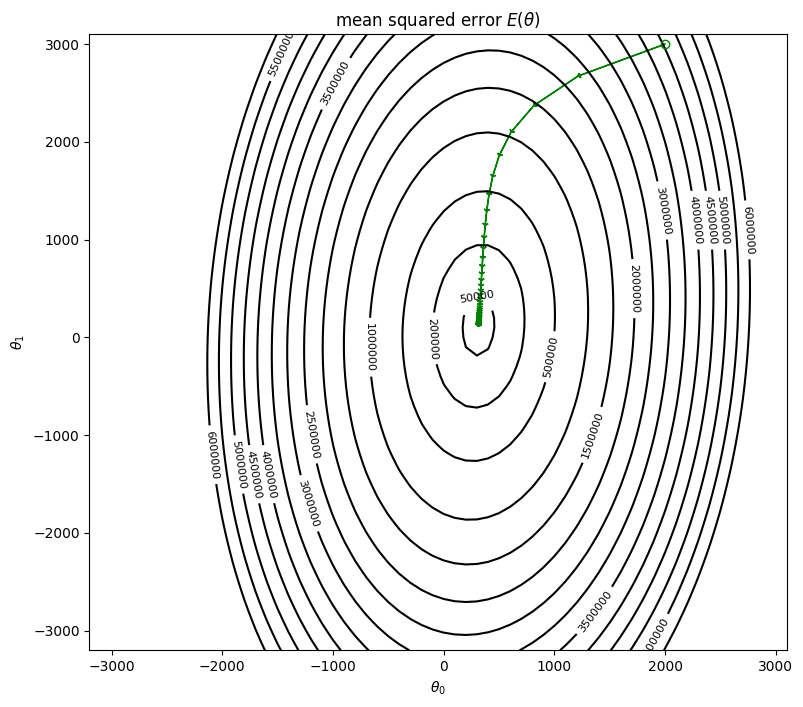

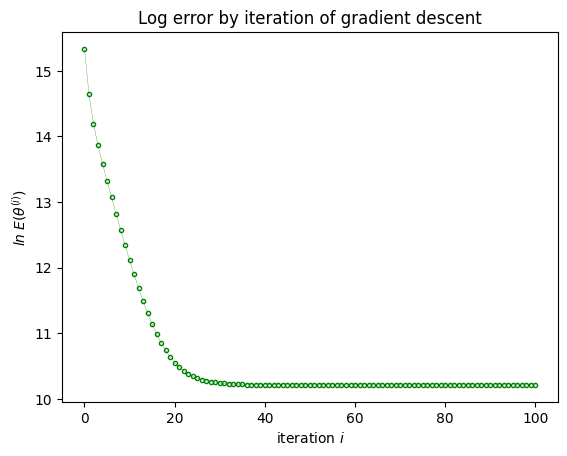

In [18]:
theta_init = np.array([2000., 3000.])
# a better starting value for theta would be [meancount, 0]

[Theta1, err1] = gradient_descent(theta_init, learning_rate = 0.25) 
print("theta after optimization: ", Theta1[:, -1])
plot_progress(Theta1, err1, col='green');

### An <span style="color:red">unsuccessful</span> run of gradient descent
If the learning rate is too high, a *local optimum* may not be found. 
If the learning rate is too small, learning can take a (prohibitively) long time.

error after  0  iterations:  4562314.689608637  gradient=  [3145.30364372 1307.64634278]
error after  10  iterations:  2580415.8635635036  gradient=  [3194.77610654 -163.01822746]
error after  20  iterations:  2792435.585558604  gradient=  [3324.69614437 -171.30746779]
error after  30  iterations:  3022064.6597415647  gradient=  [3459.98824146 -178.2802981 ]
error after  40  iterations:  3270762.6205689493  gradient=  [3600.78588584 -185.5350779 ]
error after  50  iterations:  3540112.9889356624  gradient=  [3747.31302281 -193.08507522]
error after  60  iterations:  3831830.7846824746  gradient=  [3899.8028031  -200.94230532]
error after  70  iterations:  4147773.44654477  gradient=  [4058.49786513 -209.11927047]
error after  80  iterations:  4489952.658920528  gradient=  [4223.65072105 -217.62898167]
error after  90  iterations:  4860547.1607580725  gradient=  [4395.52415851 -226.48497939]
error after  100  iterations:  5261916.618121245  gradient=  [4574.39165879 -235.70135511]
theta

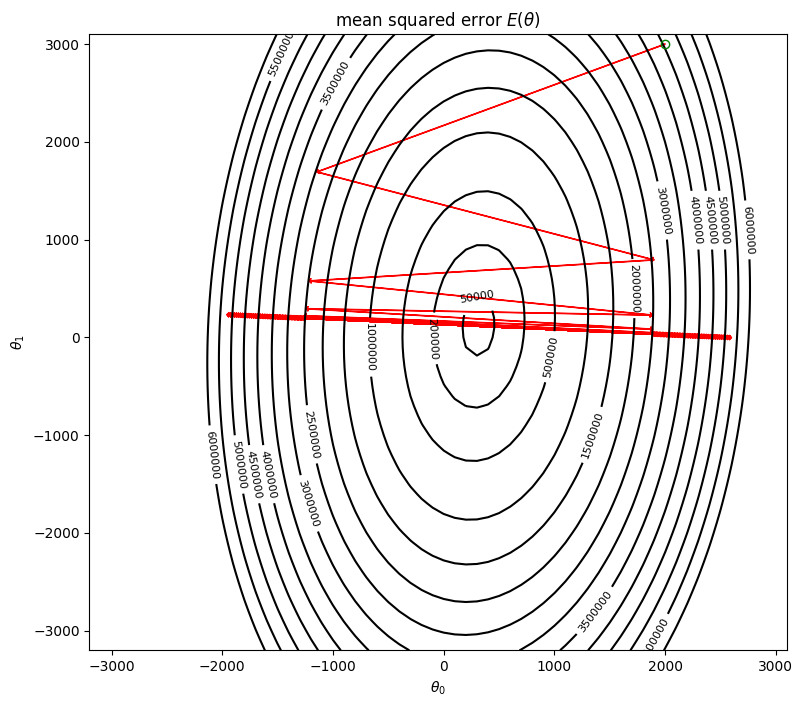

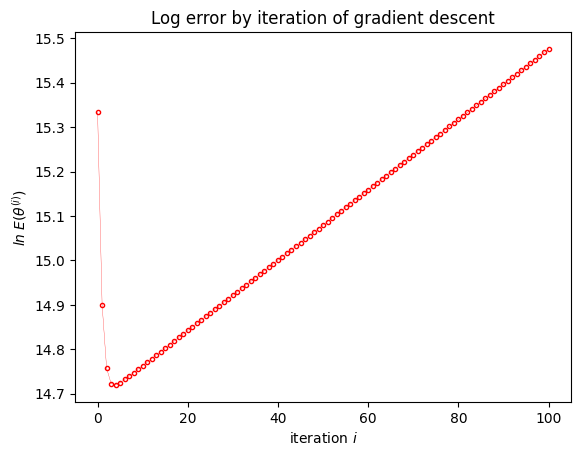

In [19]:
[Theta2, err2] = gradient_descent(theta_init, learning_rate = 1.0) # this learning rate is a little too high 
print("theta after optimization: ", Theta2[:, -1])
plot_progress(Theta2, err2, col='red');

## Solution 2: high-level approach
A high-level approach is recommended for most practical applications. For this, TensorFlow 2 uses a build-in Keras library with common ML functions and model components.

### Stochastic Gradient Descent
- Heuristics for minimizing some error or loss function $E(\pmb{\theta}; ({\bf X},{\bf y}))$ with respect to $\pmb{\theta}$ more efficiently than with regular gradient descent (Formula (2)), in particular for large training data sets $({\bf X},{\bf y})$.
- Also iteratively updates parameters $\pmb{\theta}$ on the basis of the gradient $\nabla E$, but the gradient is computed only for a (small) sample $(Xbatch, Ybatch)$ of the training data. The number of examples in the batch are called the **batch size**.
- The **learning rate** $\alpha$ plays a similar role as in regular gradient descent: The larger $\alpha$, the larger the changes to $\pmb{\theta}$ in each step.
- $0\le \mu \le 1$ is called **momentum**. If $\mu = 0$, the update step is like in regular gradient descent, except that the gradient is computed on a batch only. With increasing $\mu$ the update steps are larger and fluctuate less.
 > ${\bf v} \leftarrow {\bf 0}$  
 > While the termination condition is not satisfied
 >> Sample a random batch $(\text{Xbatch},\text{Ybatch})$ from the training data $({\bf X},{\bf y})$.  
 >> ${\bf v} \leftarrow \mu \cdot {\bf v} - \alpha \cdot \nabla E(\pmb{\theta};\text{Xbatch},\text{Ybatch}))$  
 >> $\pmb{\theta} \leftarrow \pmb{\theta} + {\bf v}$ 
  
- The termination condition could be
   1. A fixed number of iterations has been done.
   2. The accuracy/error on a separate validation set satisfies some condition (e.g. it is plateauing).
   3. User interruption.
- Often, the random choices of batches are such that the number of times each example appeared in a batch differs at most by 1, i.e. the batch is drawn from the subset of examples used hitherto one less than the maximum. Once all examples have been used once, an **epoch** ends.
- Documentation and Code of [tf.keras.optimizers.SGD](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras/optimizers/SGD)
  

In [20]:
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
# A tf.data.Dataset has commonly used functions for random sampling, obtaining subsets, transformations
# iterating over large numbers of images on disk (using TFRecord).

batch_size = 32
dataset = dataset.shuffle(m).batch(batch_size) # random order and split into batches of size 32
x,y = next(iter(dataset))
print(x.shape)
print(x)
print(y.shape)
print(y)

(32, 2)
tf.Tensor(
[[ 1.    -0.368]
 [ 1.     0.452]
 [ 1.     0.288]
 [ 1.    -0.696]
 [ 1.    -0.04 ]
 [ 1.     0.124]
 [ 1.     0.616]
 [ 1.     0.452]
 [ 1.     0.452]
 [ 1.    -0.696]
 [ 1.    -0.122]
 [ 1.    -0.45 ]
 [ 1.    -0.286]
 [ 1.     0.37 ]
 [ 1.    -0.04 ]
 [ 1.     0.206]
 [ 1.    -0.04 ]
 [ 1.     0.042]
 [ 1.     0.042]
 [ 1.     0.616]
 [ 1.     0.042]
 [ 1.    -0.286]
 [ 1.    -0.614]
 [ 1.     0.534]
 [ 1.     0.37 ]
 [ 1.     0.042]
 [ 1.    -0.04 ]
 [ 1.    -1.188]
 [ 1.    -0.04 ]
 [ 1.     0.37 ]
 [ 1.     0.206]
 [ 1.     0.042]], shape=(32, 2), dtype=float64)
(32,)
tf.Tensor(
[135. 253. 217.  14. 434. 300. 499. 593. 571. 124. 268. 299. 154. 644.
 297. 140. 776. 337. 202. 596. 538. 209. 141. 823. 170. 571. 243. 190.
 226. 258. 352. 315.], shape=(32,), dtype=float64)


In [21]:

# Get a predefined linear model with one single output variable (unit) and one weight per input.
model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)), # input layer with two features
    tf.keras.layers.Dense(
        units = 1,
        use_bias = False, # bias equivalent to adding x_0 := 1
        kernel_initializer = tf.initializers.Constant(theta_init.reshape((2, 1))), # default would be random initialization
        dtype = 'float64')])


In [22]:
optimizer = tf.keras.optimizers.SGD(learning_rate = 0.01, momentum = 0.8)
# SGD: stochastic gradient descent

loss_object = tf.keras.losses.MeanSquaredError()
# This common and preimplemented loss implements the MSE function defined in equation (1).

# we compile the model and tell the framework which loss function to use
model.compile(optimizer = optimizer, loss = loss_object)


In [23]:
# print some info about the model before training
model.summary()
# print model parameters
print ("initial parameters theta", model.get_weights())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (16.00 B)

 Trainable params: 2 (16.00 B)

 Non-trainable params: 0 (0.00 B)

initial parameters theta [array([[2000.],
       [3000.]])]


In [24]:
class CustomCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        self.theta = []
    
    def on_epoch_end(self, batch, logs=None):
        self.theta.append(tf.squeeze(model.get_weights()[0]))
        
callback = CustomCallback()

#fit the model for 5 epochs (i.e. each datapoint is seen 5 times) 
#calling this is analogous to our previously implemented low-level training loop
#it's just much simpler and in most cases what you want to use to train a model
history = model.fit(dataset, epochs=5, callbacks=[callback])

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step - loss: 2739585.0000
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - loss: 144471.5312
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - loss: 36363.7305
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step - loss: 26637.1094
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - loss: 29225.7031


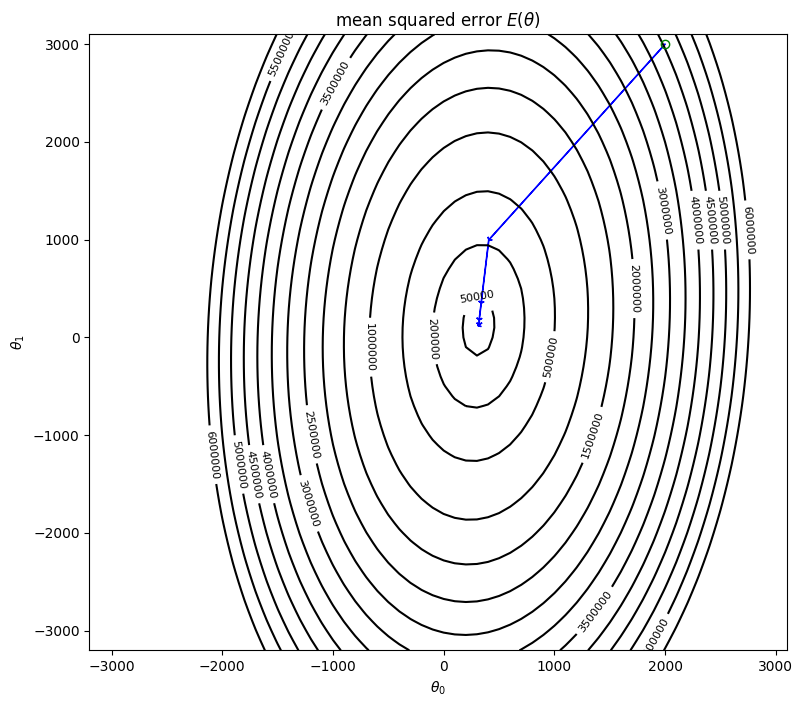

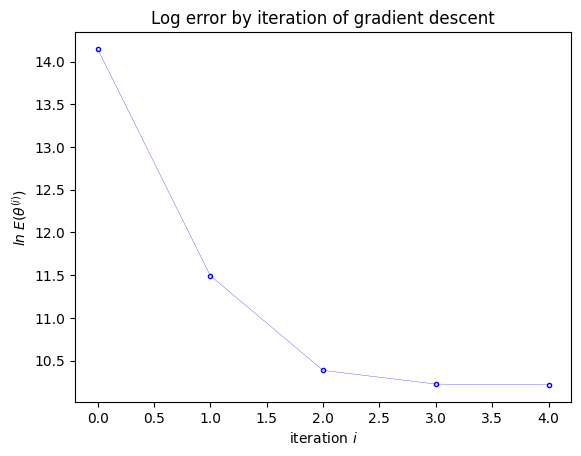

In [25]:
plot_progress(np.stack([theta_init] + callback.theta, -1), history.history["loss"], col='blue');

**Remarks:**
  - In above plot of training error, the errors were measured only on a batch and are thus estimates of the training error only.
  - When using stochastic gradient descent, typically the parameter trajectory eventually random walks near a local optimum and their latest values may result in a larger loss than some parameter value previously attained.

In [26]:
# final loss and prediction computed on all training data
pred = model(X_train)
pred = tf.reshape(pred, [m])
E = loss_object(y_train, pred)
print("final error = ", E.numpy())
print("theta:\n", model.trainable_variables[0].numpy())

final error =  27274.312
theta:
 [[308.94953046]
 [120.2558498 ]]


In [27]:
# lets compare it to our baseline error:
MSE(naive_yhat).numpy()[0]

30531.74628879892

We can see that depending on the initial parameters, we can start gradient descent a much higher error values than the baseline. So a decrease compared to the starting point of training is not enough to tell us we achieved something.

## Plot predictions

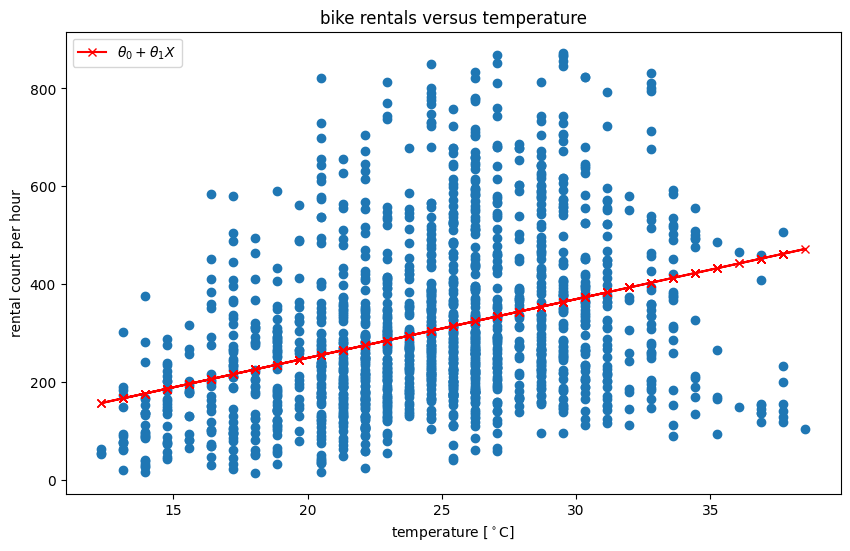

In [28]:
# draw the same scatterplot as above
ax = scatterplot_rentals()

# now add the predictions, here a regression line
ax.plot(temps, pred, 'rx-', label = r"$\theta_0 + \theta_1 X$") # - draws line connecting (r)ed crosses (x)
ax.legend(loc = 'upper left');